# 05. Experimento: quanto vale o histórico do próprio indicador?

**Motivação.** O modelo principal usa apenas features disponíveis para as duas
coortes, e 2023 foi a **primeira edição** do Indicador Criança Alfabetizada,
então a taxa municipal da edição anterior não existe para os alunos de 2023.
A partir da coorte de 2024, porém, esse histórico existe. Este experimento
responde: **quanto a taxa municipal da edição anterior adiciona ao modelo?**

**Protocolo (mesmo rigor do modelo principal):**

- Apenas alunos de **2024**; feature extra = taxa de alfabetização municipal e
  média de Português de **2023** (da `gold_indicador_municipio`; como 2023 não
  publica o recorte "Total", usamos a rede pública com prioridade
  Pública Est+Mun → Municipal → Estadual), edição anterior, sem leakage;
- `GroupKFold` (3 folds) por município, mesma proteção contra decorar
  território;
- LightGBM com os hiperparâmetros do campeão, mesma pipeline;
- Comparação pareada nos **mesmos folds**: com × sem as duas features extras;
- Subamostra agrupada de ~600 mil alunos (municípios inteiros), pelo mesmo
  limite de memória do treino principal.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, "..")
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from src.preprocessing.pipeline import (NUM_FEATURES, CAT_FEATURES, TARGET,
                                        load_dataset, make_pipeline)
from src.modeling.train import sample_grouped

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
IMG = Path("../images")
SEED = 42

PARAMS_CAMPEAO = dict(n_estimators=400, learning_rate=0.05, num_leaves=31,
                      min_child_samples=20, subsample=0.85, colsample_bytree=0.7,
                      reg_lambda=5.0, random_state=SEED, n_jobs=-1, verbosity=-1)

df = load_dataset("../data/gold_base_ml_alunos.parquet")
g23 = pd.read_parquet("../data/gold_indicador_municipio.parquet").query("ano == 2023")
# 2023 não publica o recorte 'Total'; usamos rede pública com prioridade
prioridade = {"Publica (Estadual e Municipal)": 0, "Municipal": 1, "Estadual": 2}
hist = (g23[g23["rede"].isin(prioridade)]
        .assign(_p=lambda d: d["rede"].map(prioridade))
        .sort_values("_p")
        .drop_duplicates("id_municipio")
        [["id_municipio", "taxa_alfabetizacao", "media_portugues"]]
        .rename(columns={"taxa_alfabetizacao": "taxa_municipal_2023",
                         "media_portugues": "media_portugues_2023"}))
base24 = (df[df["ano"] == 2024]
          .merge(hist, on="id_municipio", how="left"))
base24[["taxa_municipal_2023", "media_portugues_2023"]] = \
    base24[["taxa_municipal_2023", "media_portugues_2023"]].astype("float32")
cobertura = base24["taxa_municipal_2023"].notna().mean()
print(f"alunos 2024: {len(base24):,} | com histórico 2023: {cobertura:.1%}")
# trava anti-join-silencioso: se a cobertura despencar, o experimento aborta
# em vez de comparar o modelo com ele mesmo sem ninguém perceber
assert cobertura > 0.90, f"join do histórico falhou (cobertura {cobertura:.1%})"
amostra = sample_grouped(base24, 600_000)
print(f"subamostra: {len(amostra):,} alunos, {amostra['id_municipio'].nunique()} municípios")

alunos 2024: 1,852,788 | com histórico 2023: 98.1%
subamostra: 601,524 alunos, 1974 municípios


In [2]:
FEAT_BASE = CAT_FEATURES + NUM_FEATURES
FEAT_HIST = FEAT_BASE + ["taxa_municipal_2023", "media_portugues_2023"]

def cv_auc(feats, extra_num):
    # pipeline idêntica à principal; features numéricas extras entram no imputer
    import src.preprocessing.pipeline as pp
    num_original = pp.NUM_FEATURES
    pp.NUM_FEATURES = num_original + extra_num
    try:
        aucs = []
        gkf = GroupKFold(n_splits=3)
        X, y, g = amostra[feats], amostra[TARGET], amostra["id_municipio"]
        for tr, va in gkf.split(X, y, groups=g):
            pipe = make_pipeline(LGBMClassifier(**PARAMS_CAMPEAO))
            pipe.fit(X.iloc[tr], y.iloc[tr])
            aucs.append(roc_auc_score(y.iloc[va], pipe.predict_proba(X.iloc[va])[:, 1]))
        return np.array(aucs)
    finally:
        pp.NUM_FEATURES = num_original

auc_sem = cv_auc(FEAT_BASE, [])
auc_com = cv_auc(FEAT_HIST, ["taxa_municipal_2023", "media_portugues_2023"])
print(f"AUC sem histórico: {auc_sem.mean():.4f} ± {auc_sem.std():.4f}  {np.round(auc_sem, 4)}")
print(f"AUC com histórico: {auc_com.mean():.4f} ± {auc_com.std():.4f}  {np.round(auc_com, 4)}")
print(f"ganho médio: {(auc_com - auc_sem).mean():+.4f} "
      f"(pareado por fold: {np.round(auc_com - auc_sem, 4)})")

AUC sem histórico: 0.6534 ± 0.0041  [0.6478 0.6548 0.6575]
AUC com histórico: 0.6619 ± 0.0055  [0.6545 0.6636 0.6675]
ganho médio: +0.0085 (pareado por fold: [0.0066 0.0088 0.01  ])


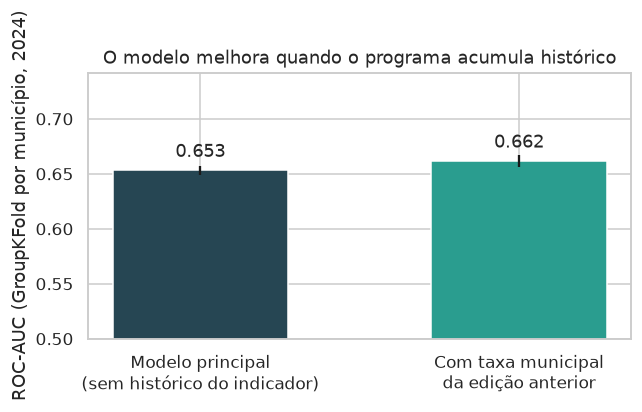

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
pos = [0, 1]
medias = [auc_sem.mean(), auc_com.mean()]
erros = [auc_sem.std(), auc_com.std()]
ax.bar(pos, medias, yerr=erros, color=["#264653", "#2a9d8f"], width=0.55)
ax.set_xticks(pos)
ax.set_xticklabels(["Modelo principal\n(sem histórico do indicador)",
                    "Com taxa municipal\nda edição anterior"])
ax.set_ylabel("ROC-AUC (GroupKFold por município, 2024)")
ax.set_ylim(0.5, max(medias) + 0.08)
for x, v in zip(pos, medias):
    ax.text(x, v + 0.012, f"{v:.3f}", ha="center")
ax.set_title("O modelo melhora quando o programa acumula histórico")
plt.tight_layout()
plt.savefig(IMG / "exp_ganho_historico.png", bbox_inches="tight")
plt.show()

## Leitura

- O histórico do próprio indicador **adiciona sinal real** mesmo com todo o
  restante do contexto presente (o ganho pareado por fold é consistente).
- Implicação operacional: o modelo principal (treinado sem essas features para
  ser comparável entre coortes) é o **piso** de desempenho. A cada nova edição
  da avaliação, a versão em produção deve incorporar a taxa da edição anterior
  e re-treinar; a precisão tende a subir com a maturidade do programa.
- Implicação para gestão: municípios são persistentes no indicador, mais um
  argumento para intervir cedo nos que o ranking aponta, em vez de esperar a
  série histórica confirmar o problema.